In [29]:
import equinox as eqx
import jax
import jax.numpy as jnp
import optax
import torch 
import torchvision 
from math import prod
from matplotlib import pyplot as plt

In [ ]:
batch_size = 512
lr_init = 1e-3
lr_final = 3e-4
latent_dim = 128
n_epochs = 50000
key = jax.random.key(0)

In [ ]:
def clipped_log(x, min):
    return jnp.clip(jnp.log(x), min=min)

def bce_loss(reconstructed, x):
    return -(x * clipped_log(reconstructed, -64) + (1 - x) * clipped_log(1 - reconstructed, -64)).mean()

def mse_loss(reconstructed, x):
    return ((x - reconstructed) ** 2).mean(axis=0).sum()

In [31]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
    ]
)
train_dataset = torchvision.datasets.CIFAR10(
    "CIFAR",
    train=True,
    download=True,
    transform=transform,
)
test_dataset = torchvision.datasets.CIFAR10(
    "CIFAR",
    train=False,
    download=True,
    transform=transform,
)
trainloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)
testloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=True
)

In [43]:
class ConvNeXtBlock(eqx.Module):
    conv1: eqx.Module
    conv2: eqx.Module
    conv3: eqx.Module
    layer_norm: eqx.Module
    act: callable
    
    def __init__(self, input_size, num_channels, key, act=jax.nn.gelu):
        keys = jax.random.split(key, 3)
        self.conv1 = eqx.nn.Conv2d(num_channels, num_channels, kernel_size=7, stride=1, padding='same', groups=num_channels, key=keys[0])
        self.conv2 = eqx.nn.Conv2d(num_channels, num_channels * 4, kernel_size=1, stride=1, padding='same', key=keys[1])
        self.conv3 = eqx.nn.Conv2d(num_channels * 4, num_channels, kernel_size=1, stride=1, padding='same', key=keys[2])
        self.layer_norm = eqx.nn.LayerNorm((num_channels, input_size, input_size))
        self.act = act

    @eqx.filter_jit
    def __call__(self, x):
        x_skip = x
        x = self.conv1(x)
        x = self.layer_norm(x)
        x = self.act(self.conv2(x))
        x = self.conv3(x) + x_skip
        return x
    
class Encoder(eqx.Module):
    convs: list[eqx.Module]
    mlp: eqx.Module
    conv_shape: tuple
    
    def __init__(self, key, image_size=32, image_channels=3, conv_channels=[32, 64, 128], num_convs=[3, 9, 3], act=jax.nn.gelu):
        key, subkey = jax.random.split(key)
        self.convs = []
        self.convs.append(eqx.nn.Conv2d(image_channels, conv_channels[0], 7, padding=3, stride=1, key=subkey))
        self.convs.append(act)
        curr_size = image_size
        for i in range(len(conv_channels)):
            self.convs.append(eqx.nn.MaxPool2d(2, 2))
            curr_size = curr_size // 2
            for _ in range(num_convs[i]):
                key, subkey = jax.random.split(key)
                self.convs.append(ConvNeXtBlock(curr_size, conv_channels[i], key=subkey))
            key, subkey = jax.random.split(key)
            if i < len(conv_channels) - 1:
                self.convs.append(eqx.nn.Conv2d(conv_channels[i], conv_channels[i + 1], 3, padding=1, stride=1, key=subkey))
                self.convs.append(act)
        self.conv_shape = (conv_channels[-1], curr_size, curr_size)
        key, subkey = jax.random.split(key)
        self.mlp = eqx.nn.MLP(prod(self.conv_shape), latent_dim, 256, 2, activation=act, key=subkey)
    
    @eqx.filter_jit
    def __call__(self, x):
        for i in range(len(self.convs)):
            x = self.convs[i](x)
        x = x.flatten()
        x = self.mlp(x)
        return x
    
class Decoder(eqx.Module):
    mlp: eqx.Module
    convs_t: list[eqx.Module]
    conv_shape: tuple
    
    def __init__(self, conv_shape, key, image_size=32, image_channels=3, conv_channels=[128, 64, 32], num_convs=[3, 9, 3], act=jax.nn.gelu):
        self.convs_t = []
        self.conv_shape = conv_shape
        key, subkey = jax.random.split(key)
        self.mlp = eqx.nn.MLP(latent_dim, prod(conv_shape), 256, 2, activation=act, key=subkey)
        curr_size = conv_shape[-1]
        for i in range(len(conv_channels)):
            for _ in range(num_convs[i]):
                key, subkey = jax.random.split(key)
                self.convs_t.append(ConvNeXtBlock(curr_size, conv_channels[i], key=subkey))
            key, subkey = jax.random.split(key)
            self.convs_t.append(eqx.nn.ConvTranspose2d(conv_channels[i], conv_channels[i + 1] if i < len(conv_channels) - 1 else image_channels, 2, stride=2, key=subkey))
            self.convs_t.append(act)
            curr_size *= 2
        key, subkey1, subkey2 = jax.random.split(key, 3)
        self.convs_t.append(ConvNeXtBlock(image_size, image_channels, subkey1))
        self.convs_t.append(ConvNeXtBlock(image_size, image_channels, subkey2))
        self.convs_t.append(jax.nn.sigmoid)
    
    @eqx.filter_jit
    def __call__(self, x):
        x = self.mlp(x)
        x = x.reshape(self.conv_shape)
        for i in range(len(self.convs_t)):
            x = self.convs_t[i](x)
        return x

class AutoEncoder(eqx.Module):
    encoder: eqx.Module
    decoder: eqx.Module
    
    def __init__(self, key, image_size=32, image_channels=3, conv_channels=[32, 64, 128], num_convs=[3, 9, 3]):
        split_keys = jax.random.split(key)
        self.encoder = Encoder(split_keys[0], image_size, image_channels, conv_channels, num_convs)
        self.decoder = Decoder(self.encoder.conv_shape, split_keys[1], image_size, image_channels, conv_channels[::-1], num_convs[::-1])
        
    @eqx.filter_jit
    def compute_latent(self, x):
        return self.encoder(x)
    
    @eqx.filter_jit
    def reconstruction(self, x):
        latent = self.compute_latent(x)
        reconstructed = self.decoder(latent)
        return reconstructed
    
    @eqx.filter_jit
    def compute_loss(autoencoder, x):
        reconstructed = jax.vmap(autoencoder.reconstruction)(x)
        loss = mse_loss(reconstructed, x)
        return loss

class VanillaVAE(AutoEncoder):
    pass

class DreamerVAE(AutoEncoder):
    pass

In [44]:
key, subkey = jax.random.split(key)
basic_autoencoder = AutoEncoder(subkey)
schedule = optax.schedules.linear_schedule(lr_init, lr_final, n_epochs)
opt = optax.adamw(schedule)
opt_state = opt.init(eqx.filter(basic_autoencoder, eqx.is_array))

In [45]:
def train_autoencoder(autoencoder, dataset, opt_state, num_steps=n_epochs):
    def train_sample(autoencoder, opt_state, x):
        loss, grads = eqx.filter_value_and_grad(type(autoencoder).compute_loss)(autoencoder, x)
        updates, opt_state = opt.update(
            grads, opt_state, eqx.filter(basic_autoencoder, eqx.is_array)
        )
        autoencoder = eqx.apply_updates(autoencoder, updates)
        return autoencoder, opt_state, loss
    
    losses = []
    jit_train_sample = eqx.filter_jit(train_sample)
    for step in range(1, num_steps + 1):
        x, _ = next(iter(dataset))
        autoencoder, opt_state, loss = jit_train_sample(autoencoder, opt_state, x.numpy())
        if step % 500 == 0:
            print(f'Step: {step}, Loss: {loss}')
        losses.append(loss)
    return autoencoder, losses
    

In [46]:
basic_autoencoder, losses = train_autoencoder(basic_autoencoder, trainloader, opt_state)

KeyboardInterrupt: 

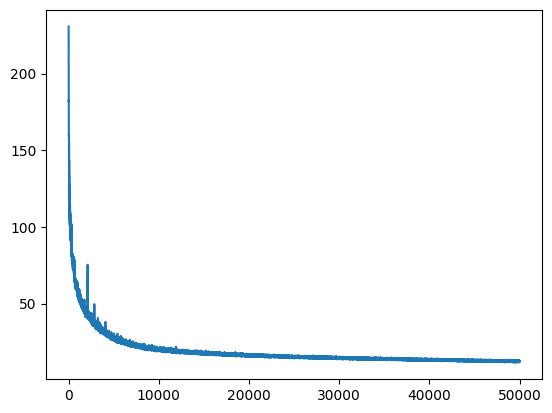

In [36]:
plt.plot(losses)

In [41]:
x_temp, y_temp = next(iter(trainloader))
x_pred = jax.vmap(basic_autoencoder.reconstruction)(x_temp.numpy())

tensor(1)


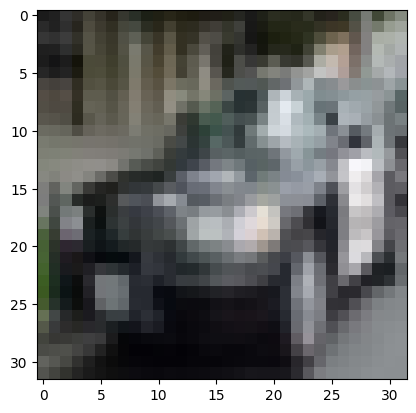

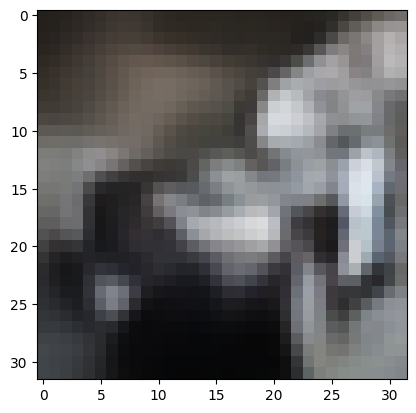

In [42]:
i = 2
print(y_temp[i])
plt.imshow(x_temp[i].numpy().transpose(1, 2, 0))
plt.show()
plt.imshow(x_pred[i].transpose(1, 2, 0))

In [48]:
from torchvision.datasets import ImageFolder
import json

In [54]:
transform = torchvision.transforms.Compose([
        torchvision.transforms.Resize((128, 128)),
        torchvision.transforms.ToTensor()
    ])

labels = json.load(open('ImageNet100/Labels.json'))
keys = list(labels.keys())
imagenet100 = ImageFolder('ImageNet100/val.X', transform=transform)#, target_transform=lambda x: labels[keys[x]])
trainloader = torch.utils.data.DataLoader(
    imagenet100, batch_size=batch_size, shuffle=True
)

In [55]:
batch_size = 128
lr_init = 1e-3
lr_final = 3e-4
latent_dim = 128

key, subkey = jax.random.split(key)
basic_autoencoder = AutoEncoder(subkey, image_size=128, conv_channels=[16, 32, 64, 128], num_convs=[3, 3, 9, 3])
schedule = optax.schedules.linear_schedule(lr_init, lr_final, n_epochs)
opt = optax.adamw(schedule)
opt_state = opt.init(eqx.filter(basic_autoencoder, eqx.is_array))

Step: 500, Loss: 1524.52685546875
Step: 1000, Loss: 1149.923583984375
Step: 1500, Loss: 879.7373657226562
Step: 2000, Loss: 676.9534912109375
Step: 2500, Loss: 599.8585205078125
Step: 3000, Loss: 566.9720458984375
Step: 3500, Loss: 500.37811279296875
Step: 4000, Loss: 483.1589660644531
Step: 4500, Loss: 471.29168701171875
Step: 5000, Loss: 420.9537658691406
Step: 5500, Loss: 413.8192138671875
Step: 6000, Loss: 405.7730712890625
Step: 6500, Loss: 391.63873291015625
Step: 7000, Loss: 327.11065673828125
Step: 7500, Loss: 371.3944396972656
Step: 8000, Loss: 370.8437194824219
Step: 8500, Loss: 344.9735107421875
Step: 9000, Loss: 317.83514404296875
Step: 9500, Loss: 306.7894287109375
Step: 10000, Loss: 321.56695556640625
Step: 10500, Loss: 332.37896728515625
Step: 11000, Loss: 323.27947998046875
Step: 11500, Loss: 302.1703796386719
Step: 12000, Loss: 316.8675842285156
Step: 12500, Loss: 290.6083068847656
Step: 13000, Loss: 276.3727722167969
Step: 13500, Loss: 271.00811767578125
Step: 14000, 

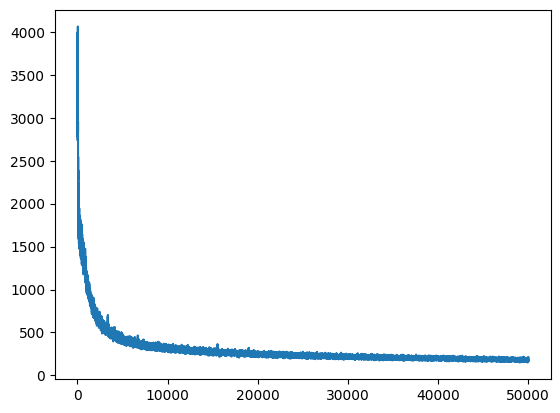

In [57]:
basic_autoencoder, losses = train_autoencoder(basic_autoencoder, trainloader, opt_state)
plt.plot(losses)

In [58]:
x_temp, y_temp = next(iter(trainloader))
x_pred = jax.vmap(basic_autoencoder.reconstruction)(x_temp.numpy())

tensor(33)


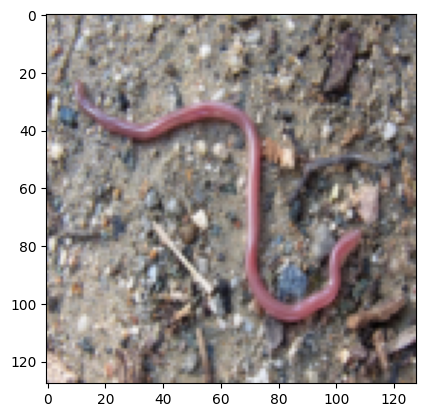

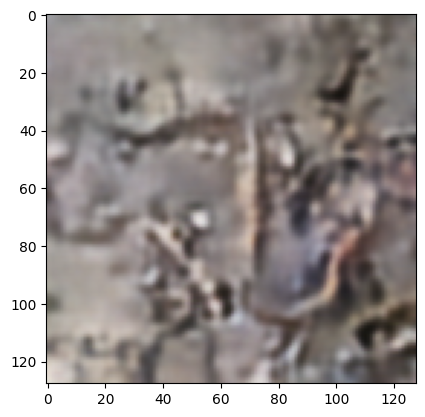

In [61]:
i = 3
print(y_temp[i])
plt.imshow(x_temp[i].numpy().transpose(1, 2, 0))
plt.show()
plt.imshow(x_pred[i].transpose(1, 2, 0))

In [62]:
eqx.tree_serialise_leaves("imagenet100_ae.eqx", basic_autoencoder)